### Analise da importancia das keywords no contexto da seleção para a SLR 1

Vamos olhar o quanto as palavras chaves impactam no processo de seleção

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import openai
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### style de execução
tqdm.pandas()

In [3]:
# 1. Configurar para exibir todas as linhas
pd.set_option('display.max_rows', None)

# 2. Configurar para exibir todas as colunas
pd.set_option('display.max_columns', None)

### variaveis de ambiente e conexões

In [ ]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

In [ ]:
for key in os.environ.keys():
    print(f'{key}')

In [ ]:
def create_client(key_env):
    """
    Passa a chave do ambiente local para definir a conexao
    """
    client = openai.OpenAI(api_key = os.getenv(key_env))
    return client

In [ ]:
client = openai.OpenAI(api_key = os.getenv('OPENAI_API_KEY_GOV_ANALITICA'))

# LLMs da Openai
-----

### Leitura dos arquivos

In [ ]:
df_slr1 = pd.read_excel("/data/codigos/dados/titulo_resumo_palavras_slr1_v2.xlsx",engine='openpyxl')
df_slr1.head()

In [ ]:
df_slr1 = df_slr1.replace({r'_x000D_|\n': ''}, regex=True)

In [ ]:
df_slr1.head()

#### Limpeza dos casos em que não conseguimos extrair as informações


In [ ]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts = df_slr1['sucesso_fracasso_resumo'].value_counts()
print(sucesso_fracasso_counts)

In [ ]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts2 = df_slr1['sucesso_fracasso_palavras'].value_counts()
print(sucesso_fracasso_counts2)

In [ ]:
# aqui precisamos, para reproduzir o artigo que ambos os campos tenho informação
df_slr1_clear = df_slr1.loc[((df_slr1['sucesso_fracasso_resumo'].isin(['sucesso']))&(df_slr1['sucesso_fracasso_palavras'].isin(['sucesso'])))].copy()
df_slr1_clear.shape

In [ ]:
df_slr1_clear.head()

In [ ]:
# vamos amostrar em 50 amostras da slr 1 por uma questão de custo
df_slr1_sample = df_slr1_clear.sample(n=50, random_state=42)
df_slr1_sample.shape

In [ ]:
# Renomear as colunas do dataframe df_slr1_clear
df_slr1_sample.rename(columns={"Title": "title", "resumo": "abstract"}, inplace=True)
df_slr1_sample.head(2)

In [ ]:
# titulo+resumo
df_slr1_titulo_resumo = df_slr1_sample[["ID",'title','abstract']].copy()
df_slr1_titulo_resumo.head(2)

In [ ]:
#resumo+keywords
df_slr1_resumo_keywords = df_slr1_sample[["ID",'abstract','keywords']].copy()
df_slr1_resumo_keywords.head(2)

In [ ]:
# titlo+keywords
df_slr1_titulo_keywords = df_slr1_sample[["ID",'title','keywords']].copy()
df_slr1_titulo_keywords.head(2)

In [ ]:
# resumo
df_slr1_resumo = df_slr1_sample[["ID",'abstract']].copy()
df_slr1_resumo.head(2)

# Openai

#### configuracoes iniciais

In [ ]:
def process_selection_with_gpt(model_gpt, title, abstract, keywords,inclusion_criteria_question,client,type_selection):
    """
    realiza a seleção dos artigos usando a escala likert, conforme o artigo original
    """
    
    # Contexto final para responder as perguntas
    system_message = {
        "role": "system", 
        "content": """Assume you are a software engineering researcher. 
        Conducting a systematic literature review (SLR). Consider the title, abstract and keywords of a primary study"""
    }

    # Prompt final com as perguntas

    # Prompt final com as perguntas, aprimorado para o último bloco
    if type_selection == 'resumo_keywords':
        user_message = { "role": "user",
                         "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Abstract: {abstract}\n Keywords: {keywords}"""
                    }
    elif type_selection == 'titulo_resumo':
        user_message = { "role": "user",
                         "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Title: {title}\n Abstract: {abstract}"""
                    }
    elif type_selection == 'titulo_keywords':
        user_message = { "role": "user",
                         "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Title: {title}\n Keywords: {keywords}"""
                    }
    elif type_selection == 'resumo':
        user_message = { "role": "user",
                         "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Abstract: {abstract}"""
                    }
    
   
    # Criação da chamada para a API
    response = client.chat.completions.create(
        model=model_gpt,
        messages=[system_message, user_message],
        temperature=0,
        max_tokens=1,
        top_p=0.1
    )

    try:
        resposta = int(response.choices[0].message.content)
    except Exception as e:
        resposta = response.choices[0].message.content
        print("Erro ao processar:", e)
        print(str(response.choices[0].message.content))
        print(str(title))

    return resposta

In [ ]:
def repeat_selection_with_gpt(df, model_gpt, inclusion_criteria_question, client,n_interactions,name_ic,type_selection):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        print(i)
        coluna_aux = model_gpt+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp_slr1{type_selection}_{model_gpt}_{name_ic}_iter_{i}_v2.xlsx"
        if type_selection == 'resumo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gpt(model_gpt,
                                                                                    np.nan,
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gpt(model_gpt,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    np.nan,
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gpt(model_gpt,
                                                                                    row['title'],
                                                                                    np.nan,
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gpt(model_gpt,
                                                                                        np.nan,
                                                                                        row['abstract'],
                                                                                        np.nan,
                                                                                        inclusion_criteria_question,
                                                                                        client,
                                                                                        type_selection), axis=1)
         # salvando para nao perder
        df.to_excel(temp_filename, index=False)
    return df

#### titulo_resumo

In [ ]:
df_slr1_titulo_resumo_gpt = df_slr1_titulo_resumo.copy()

In [ ]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4o" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "titulo_resumo"
df_slr1_titulo_resumo_gpt = repeat_selection_with_gpt(df = df_slr1_titulo_resumo_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4o" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "titulo_resumo"
df_slr1_titulo_resumo_gpt = repeat_selection_with_gpt(df = df_slr1_titulo_resumo_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_titulo_resumo_gpt.to_excel("/data/codigos/dados/resultados/titulo_resumo_openai_gpt_4o_slr1_v2.xlsx", index=False)
df_slr1_titulo_resumo_gpt.to_csv("/data/codigos/dados/resultados/titulo_resumo_openai_gpt_4o_slr1_v2.csv", encoding='utf-8', index=False)

#### titulo_keywords

In [ ]:
df_slr1_titulo_keywords_gpt = df_slr1_titulo_keywords.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4o" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "titulo_keywords"
df_slr1_titulo_keywords_gpt = repeat_selection_with_gpt(df = df_slr1_titulo_keywords_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4o" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "titulo_keywords"
df_slr1_titulo_keywords_gpt = repeat_selection_with_gpt(df = df_slr1_titulo_keywords_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_titulo_keywords_gpt.to_excel("/data/codigos/dados/resultados/titulo_keywords_openai_gpt_4o_slr1_v2.xlsx", index=False)
df_slr1_titulo_keywords_gpt.to_csv("/data/codigos/dados/resultados/titulo_keywords_openai_gpt_4o_slr1_v2.csv", encoding='utf-8', index=False)

#### resumo_keywords

In [ ]:
df_slr1_resumo_keywords_gpt = df_slr1_resumo_keywords.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4o" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "resumo_keywords"
df_slr1_resumo_keywords_gpt = repeat_selection_with_gpt(df = df_slr1_resumo_keywords_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4o" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "resumo_keywords"
df_slr1_resumo_keywords_gpt = repeat_selection_with_gpt(df = df_slr1_resumo_keywords_gpt,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
df_slr1_resumo_keywords_gpt.to_excel("/data/codigos/dados/resultados/resumo_keywords_openai_gpt_4o_slr1_v2.xlsx", index=False)
df_slr1_resumo_keywords_gpt.to_csv("/data/codigos/dados/resultados/resumo_keywords_openai_gpt_4o_slr1_v2.csv", encoding='utf-8', index=False)

#### resumo

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4o" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "resumo"
df_slr1_resumo = repeat_selection_with_gpt(df = df_slr1_resumo,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "gpt-4o" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "resumo"
df_slr1_resumo = repeat_selection_with_gpt(df = df_slr1_resumo,
                                        model_gpt = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        type_selection=type_selection)

In [ ]:
df_slr1_resumo.to_excel("/data/codigos/dados/resultados/resumo_openai_gpt_4o_slr1_v2.xlsx", index=False)
df_slr1_resumo.to_csv("/data/codigos/dados/resultados/resumo_openai_gpt_4o_slr1_v2.csv", encoding='utf-8', index=False)

# GOOGLE

#### configuracoes iniciais

In [ ]:
import google.generativeai as genai

In [ ]:
# Configurar a chave de API
genai.configure(api_key=os.getenv("GOOGLE_API_KEY_LLMS_PROF_DANILO"))

In [ ]:
def process_selection_with_gemini(model_gemini, title,abstract, keywords, inclusion_criteria_question,type_selection):
    """
    Realiza a seleção dos artigos usando a escala Likert com o modelo Gemini.
    """
    
    # Criar um modelo Gemini-Pro
    model = genai.GenerativeModel(model_gemini)

    # Construção do prompt
    if type_selection == 'resumo_keywords':
        texto_aux = f"""  
            **Abstract:** {abstract}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'titulo_resumo':
        texto_aux = f"""  
            **Title:** {title}  
            **Abstract:** {abstract}
            """
    elif type_selection == 'titulo_keywords':
        texto_aux = f"""  
            **Title:** {title}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'resumo':
        texto_aux = f"""  
            **Abstract:** {abstract}
            """



    prompt = f"""
    Assume you are a software engineering researcher conducting a systematic literature review (SLR).
    Consider the title, abstract and keywords of study.

    Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
    {texto_aux}
    Return Only number, not symbols or letters.
    """

    # Fazer a chamada à API do Gemini
    response = model.generate_content(prompt)

    try:
        resposta = int(response.text.strip())  # Converte a resposta para número inteiro
        return resposta
    except ValueError:
        print("Erro ao processar a resposta:", response.text)
        return None


In [ ]:
def repeat_selection_with_gemini(df, model_gemini, inclusion_criteria_question,n_interactions,name_ic,type_selection):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        coluna_aux = model_gemini+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp__slr1_{type_selection}_{model_gemini}_{name_ic}_iter_{i}_v2.xlsx"
        
        if type_selection == 'resumo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gemini(model_gemini,
                                                                                    np.nan,
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gemini(model_gemini,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    np.nan,
                                                                                    inclusion_criteria_question,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gemini(model_gemini,
                                                                                    row['title'],
                                                                                    np.nan,
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    type_selection), axis=1)
        elif type_selection == 'resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_gemini(model_gemini,
                                                                                        np.nan,
                                                                                        row['abstract'],
                                                                                        np.nan,
                                                                                        inclusion_criteria_question,
                                                                                        type_selection), axis=1)
         # salvando para nao perder
        df.to_excel(temp_filename, index=False)
        time.sleep(5)  # Aguarda 60 segundos entre as chamadas para evitar exceder o limite de uso da API
    return df

In [ ]:
# paramentros globais
n_interactions = 5  # fixemos em 10 vezes devido ao custo

#### resumo_keywords

In [ ]:
df_slr1_resumo_keywords_google = df_slr1_resumo_keywords.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-1.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "resumo_keywords"
df_slr1_resumo_keywords_google = repeat_selection_with_gemini(df = df_slr1_resumo_keywords_google,
                                                    model_gemini = model_gemini,
                                                    inclusion_criteria_question = inclusion_criteria_question,
                                                    n_interactions = n_interactions,
                                                    name_ic = name_ic,
                                                    type_selection=type_selection)


In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-1.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "resumo_keywords"
df_slr1_resumo_keywords_google = repeat_selection_with_gemini(df = df_slr1_resumo_keywords_google,
                                                model_gemini = model_gemini,
                                                inclusion_criteria_question = inclusion_criteria_question,
                                                n_interactions = n_interactions,
                                                name_ic = name_ic,
                                                type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_resumo_keywords_google.to_excel("/data/codigos/dados/resultados/resumo_keywords_gemini_15_flash_slr1_V2.xlsx", index=False)
df_slr1_resumo_keywords_google.to_csv("/data/codigos/dados/resultados/resumo_keywords_gemini_15_flash_slr1_V2.csv", encoding='utf-8', index=False)

#### titulo_resumo

In [ ]:
df_slr1_titulo_resumo_google = df_slr1_titulo_resumo.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-1.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "titulo_resumo"
df_slr1_titulo_resumo_google = repeat_selection_with_gemini(df = df_slr1_titulo_resumo_google,
                                                    model_gemini = model_gemini,
                                                    inclusion_criteria_question = inclusion_criteria_question,
                                                    n_interactions = n_interactions,
                                                    name_ic = name_ic,
                                                    type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-1.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "titulo_resumo"
df_slr1_titulo_resumo_google = repeat_selection_with_gemini(df = df_slr1_titulo_resumo_google,
                                                model_gemini = model_gemini,
                                                inclusion_criteria_question = inclusion_criteria_question,
                                                n_interactions = n_interactions,
                                                name_ic = name_ic,
                                                type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_titulo_resumo_google.to_excel("/data/codigos/dados/resultados/titulo_resumo_gemini_15_flash_slr1_v2.xlsx", index=False)
df_slr1_titulo_resumo_google.to_csv("/data/codigos/dados/resultados/titulo_resumo_gemini_15_flash_slr1_v2.csv", encoding='utf-8', index=False)

#### titulo_keywords

In [ ]:
df_slr1_titulo_keywords_google = df_slr1_titulo_keywords.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-1.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "titulo_keywords"
df_slr1_titulo_keywords_google = repeat_selection_with_gemini(df = df_slr1_titulo_keywords_google,
                                                    model_gemini = model_gemini,
                                                    inclusion_criteria_question = inclusion_criteria_question,
                                                    n_interactions = n_interactions,
                                                    name_ic = name_ic,
                                                    type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-1.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "titulo_keywords"
df_slr1_titulo_keywords_google = repeat_selection_with_gemini(df = df_slr1_titulo_keywords_google,
                                                model_gemini = model_gemini,
                                                inclusion_criteria_question = inclusion_criteria_question,
                                                n_interactions = n_interactions,
                                                name_ic = name_ic,
                                                type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_titulo_keywords_google.to_excel("/data/codigos/dados/resultados/titulo_keywords_gemini_15_flash_slr1_v2.xlsx", index=False)
df_slr1_titulo_keywords_google.to_csv("/data/codigos/dados/resultados/titulo_keywords_gemini_15_flash_slr1_v2.csv", encoding='utf-8', index=False)

#### resumo

In [ ]:
df_slr1_resumo_google= df_slr1_resumo.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-1.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "resumo"
df_slr1_resumo_google = repeat_selection_with_gemini(df = df_slr1_resumo_google,
                                                    model_gemini = model_gemini,
                                                    inclusion_criteria_question = inclusion_criteria_question,
                                                    n_interactions = n_interactions,
                                                    name_ic = name_ic,
                                                    type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_gemini = "gemini-1.5-flash" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "resumo"
df_slr1_resumo_google = repeat_selection_with_gemini(df = df_slr1_resumo_google,
                                                model_gemini = model_gemini,
                                                inclusion_criteria_question = inclusion_criteria_question,
                                                n_interactions = n_interactions,
                                                name_ic = name_ic,
                                                type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_resumo_google.to_excel("/data/codigos/dados/resultados/resumo_gemini_15_flash_slr1_v2.xlsx", index=False)
df_slr1_resumo_google.to_csv("/data/codigos/dados/resultados/resumo_gemini_15_flash_slr1_v2.csv", encoding='utf-8', index=False)

# Antropic

### Configuracoes iniciais

In [ ]:
import anthropic

In [ ]:
# Configurar a chave de API
client = anthropic.Anthropic(api_key=os.getenv("ANTROPIC_API_KEY_LLMS"))

In [ ]:
def process_selection_with_anthropic(model_anthropic, title, abstract, keywords, 
                                     inclusion_criteria_question,client, type_selection):
    """
    Realiza a seleção dos artigos usando a escala Likert com o modelo da Anthropic.
    """
    
    # Construção do prompt
    # Construção do prompt
    if type_selection == 'resumo_keywords':
        texto_aux = f"""  
            **Abstract:** {abstract}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'titulo_resumo':
        texto_aux = f"""  
            **Title:** {title}  
            **Abstract:** {abstract}
            """
    elif type_selection == 'titulo_keywords':
        texto_aux = f"""  
            **Title:** {title}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'resumo':
        texto_aux = f"""  
            **Abstract:** {abstract}
            """
        

    prompt = f"""
    Assume you are a software engineering researcher conducting a systematic literature review (SLR).
    Considering the title, abstract, and keywords of a primary study.

    Using a Likert scale from 1 to 7 (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree,
    4 - Neutral, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree), rate your agreement 
    with the following question:  

    "{inclusion_criteria_question}"
    
    About the article:  
    {texto_aux}

    Only return a number from 1 to 7, without any additional explanation, not symbols.
    """

    # Fazer a chamada à API da Anthropic
    response = client.messages.create(
        model=model_anthropic,
        max_tokens=2,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    try:
    # Verifica se há conteúdo na resposta
        if response.content and len(response.content) > 0:
            resposta = int(response.content[0].text.strip())
            return resposta
        else:
            print("Resposta vazia da API Anthropic.")
            return None
    except Exception as e:
        print("Erro ao processar a resposta:", getattr(response, "content", "Sem conteúdo"))
        print("Exceção:", e)
        return None

In [ ]:
texto_aux = f"""  
        **Título:** {df_slr1_titulo_resumo['title'][0]}  
        **Resumo:** {df_slr1_titulo_resumo['abstract'][0]}
        """
texto_aux

In [ ]:
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""

In [ ]:
prompt = f"""
   Assume you are a software engineering researcher conducting a systematic literature review (SLR).
   Considering the title, abstract, and keywords of a primary study.

   Using a Likert scale from 1 to 7 (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree,
   4 - Neutral, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree), rate your agreement 
   with the following question:  

   "{inclusion_criteria_question}"
   
   About the article:  
   {texto_aux}

   Only return a number from 1 to 7, without any additional explanation, not symbols, do not return empty.
   """

In [ ]:
 # Fazer a chamada à API da Anthropic
response = client.messages.create(
    model="claude-3-5-haiku-20241022",
    max_tokens=1,
    messages=[
        {"role": "user", "content": prompt}
    ]
)


In [ ]:
try:
# Verifica se há conteúdo na resposta
    if response.content and len(response.content) > 0:
        #resposta = int(response.content[0].text.strip())
        response
    else:
        print("Resposta vazia da API Anthropic.")
        
except Exception as e:
    print("Erro ao processar a resposta:", getattr(response, "content", "Sem conteúdo"))
    print("Exceção:", e)
    

In [ ]:
int(response.content[0].text.strip())

In [ ]:
def repeat_selection_with_antropic(df, model_anthropic, inclusion_criteria_question,n_interactions,name_ic,
                                   client,type_selection):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        coluna_aux = model_anthropic+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp_slr1_{type_selection}_{model_anthropic}_{name_ic}_iter_{i}_v2.xlsx"
        if type_selection == 'resumo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_anthropic(model_anthropic,
                                                                                    np.nan,
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_anthropic(model_anthropic,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    np.nan,
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_anthropic(model_anthropic,
                                                                                    row['title'],
                                                                                    np.nan,
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_anthropic(model_anthropic,
                                                                                        np.nan,
                                                                                        row['abstract'],
                                                                                        np.nan,
                                                                                        inclusion_criteria_question,
                                                                                        client,
                                                                                        type_selection), axis=1)
        # salvando para nao perder
        df.to_excel(temp_filename, index=False)
        time.sleep(15)  # Aguarda 60 segundos entre as chamadas para evitar exceder o limite de uso da API
    return df

In [ ]:
n_interactions=5

### titulo_resumo

In [ ]:
df_slr1_titulo_resumo_antropic = df_slr1_titulo_resumo.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-haiku-20241022"
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "titulo_resumo"
df_slr1_titulo_resumo_antropic = repeat_selection_with_antropic(df = df_slr1_titulo_resumo_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-haiku-20241022"
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "titulo_resumo"
df_slr1_titulo_resumo_antropic = repeat_selection_with_antropic(df = df_slr1_titulo_resumo_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_titulo_resumo_antropic.to_excel("/data/codigos/dados/resultados/titulo_resumo_claude_haiku_35_slr1_v2.xlsx", index=False)
df_slr1_titulo_resumo_antropic.to_csv("/data/codigos/dados/resultados/titulo_resumo_claude_haiku_35_slr1_v2.csv", encoding='utf-8', index=False)

### resumo_keywords

In [ ]:
df_slr1_resumo_keywords_antropic = df_slr1_resumo_keywords.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-haiku-20241022"
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "resumo_keywords"
df_slr1_resumo_keywords_antropic = repeat_selection_with_antropic(df = df_slr1_resumo_keywords_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-haiku-20241022"
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "resumo_keywords"
df_slr1_resumo_keywords_antropic = repeat_selection_with_antropic(df = df_slr1_resumo_keywords_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_resumo_keywords_antropic.to_excel("/data/codigos/dados/resultados/resumo_keywords_claude_haiku_35_slr1_v2.xlsx", index=False)
df_slr1_resumo_keywords_antropic.to_csv("/data/codigos/dados/resultados/resumo_keywords_claude_haiku_35_slr1_v2.csv", encoding='utf-8', index=False)

### titulo_keywords

In [ ]:
df_slr1_titulo_keywords_antropic = df_slr1_titulo_keywords.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-haiku-20241022"
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "titulo_keywords"
df_slr1_titulo_keywords_antropic = repeat_selection_with_antropic(df = df_slr1_titulo_keywords_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-haiku-20241022"
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "titulo_keywords"
df_slr1_titulo_keywords_antropic = repeat_selection_with_antropic(df = df_slr1_titulo_keywords_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_titulo_keywords_antropic.to_excel("/data/codigos/dados/resultados/titulo_keywords_claude_haiku_35_slr1_v2.xlsx", index=False)
df_slr1_titulo_keywords_antropic.to_csv("/data/codigos/dados/resultados/titulo_keywords_claude_haiku_35_slr1_v2.csv", encoding='utf-8', index=False)

### resumo

In [ ]:
df_slr1_resumo_antropic= df_slr1_resumo.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-haiku-20241022"
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "resumo"
df_slr1_resumo_antropic = repeat_selection_with_antropic(df = df_slr1_resumo_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_anthropic = "claude-3-5-haiku-20241022"
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "resumo"
df_slr1_resumo_antropic = repeat_selection_with_antropic(df = df_slr1_resumo_antropic,
                                        model_anthropic = model_anthropic,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_resumo_antropic.to_excel("/data/codigos/dados/resultados/resumo_claude_haiku_35_slr1_v2.xlsx", index=False)
df_slr1_resumo_antropic.to_csv("/data/codigos/dados/resultados/resumo_claude_haiku_35_slr1_v2.csv", encoding='utf-8', index=False)

# META

In [ ]:
from together import Together

In [ ]:
client = Together(api_key = os.getenv('TOGETHER_API_KEY_LLMS'))

In [ ]:
def process_selection_with_meta(model_meta, title, abstract, keywords, 
                                     inclusion_criteria_question,client, type_selection):
    """
    Realiza a seleção dos artigos usando a escala Likert com o modelo da meta.
    """
    
    # Construção do prompt
    # Construção do prompt
    if type_selection == 'resumo_keywords':
        texto_aux = f"""  
            **Abstract:** {abstract}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'titulo_resumo':
        texto_aux = f"""  
            **Title:** {title}  
            **Abstract:** {abstract}
            """
    elif type_selection == 'titulo_keywords':
        texto_aux = f"""  
            **Title:** {title}  
            **Keywords:** {keywords}
            """
    elif type_selection == 'resumo':
        texto_aux = f"""  
            **Abstract:** {abstract}
            """
        

    prompt = f"""
    Assume you are a software engineering researcher conducting a systematic literature review (SLR).
    Considering the title, abstract, and keywords of a primary study.

    Using a Likert scale from 1 to 7 (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree,
    4 - Neutral, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree), rate your agreement 
    with the following question:  

    "{inclusion_criteria_question}"
    
    About the article:  
    {texto_aux}

    Only return a number from 1 to 7, without any additional explanation, not symbols.
    """

    # Fazer a chamada à API da together
    response = client.chat.completions.create(
        model="meta-llama/"+model_meta,
        max_tokens=2,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )

    try:
        resposta = int(response.choices[0].message.content)
    except Exception as e:
        resposta = response.choices[0].message.content
        print("Erro ao processar:", e)
        print(str(response.choices[0].message.content))
        print(str(title))
        return None

    return resposta

In [ ]:
def repeat_selection_with_meta(df, model_meta, inclusion_criteria_question,n_interactions,name_ic,
                                   client,type_selection):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        coluna_aux = model_anthropic+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp_slr1_{type_selection}_{model_meta}_{name_ic}_iter_{i}_v2.xlsx"
        if type_selection == 'resumo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_meta(model_meta,
                                                                                    np.nan,
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_meta(model_meta,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    np.nan,
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'titulo_keywords':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_meta(model_meta,
                                                                                    row['title'],
                                                                                    np.nan,
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client,
                                                                                    type_selection), axis=1)
        elif type_selection == 'resumo':
            df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_meta(model_meta,
                                                                                        np.nan,
                                                                                        row['abstract'],
                                                                                        np.nan,
                                                                                        inclusion_criteria_question,
                                                                                        client,
                                                                                        type_selection), axis=1)
        # salvando para nao perder
        df.to_excel(temp_filename, index=False)
        time.sleep(15)  # Aguarda 60 segundos entre as chamadas para evitar exceder o limite de uso da API
    return df

In [ ]:
n_interactions=5

### titulo_resumo

In [ ]:
df_slr1_titulo_resumo_meta = df_slr1_titulo_resumo.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "titulo_resumo"
df_slr1_titulo_resumo_meta = repeat_selection_with_meta(df = df_slr1_titulo_resumo_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "titulo_resumo"
df_slr1_titulo_resumo_meta = repeat_selection_with_meta(df = df_slr1_titulo_resumo_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_titulo_resumo_meta.to_excel("/data/codigos/dados/resultados/titulo_resumo_llama_4_scout_17B_16E_instruct_slr1_v2.xlsx", index=False)
df_slr1_titulo_resumo_meta.to_csv("/data/codigos/dados/resultados/titulo_resumo_llama_4_scout_17B_16E_instruct_slr1_v2.csv", encoding='utf-8', index=False)

In [ ]:
df_slr1_titulo_resumo_meta.head(4)

### Resumo_keywords

In [ ]:
df_slr1_resumo_keywords_meta = df_slr1_resumo_keywords.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "resumo_keywords"
df_slr1_resumo_keywords_meta = repeat_selection_with_meta(df = df_slr1_resumo_keywords_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "resumo_keywords"
df_slr1_resumo_keywords_meta = repeat_selection_with_meta(df = df_slr1_resumo_keywords_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_resumo_keywords_meta.to_excel("/data/codigos/dados/resultados/resumo_keywords_llama_4_scout_17B_16E_instruct_slr1_v2.xlsx", index=False)
df_slr1_resumo_keywords_meta.to_csv("/data/codigos/dados/resultados/resumo_keywords_llama_4_scout_17B_16E_instruct_slr1_v2.csv", encoding='utf-8', index=False)

### titulo_keywords

In [ ]:
df_slr1_titulo_keywords_meta = df_slr1_titulo_keywords.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "titulo_keywords"
df_slr1_titulo_keywords_meta = repeat_selection_with_meta(df = df_slr1_titulo_keywords_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)


In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "titulo_keywords"
df_slr1_titulo_keywords_meta = repeat_selection_with_meta(df = df_slr1_titulo_keywords_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_titulo_keywords_meta.to_excel("/data/codigos/dados/resultados/titulo_keywords_llama_4_scout_17b_16e_instruct_slr1_v2.xlsx", index=False)
df_slr1_titulo_keywords_meta.to_csv("/data/codigos/dados/resultados/titulo_keywords_llama_4_scout_17b_16e_instruct_slr1_v2.csv", encoding='utf-8', index=False)

### resumo

In [ ]:
df_slr1_resumo_meta = df_slr1_resumo.copy()

In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
type_selection = "resumo"
df_slr1_resumo_meta = repeat_selection_with_meta(df = df_slr1_resumo_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client = client,
                                        type_selection=type_selection)


In [ ]:
# repetir o mesmo processamento n vezes
model_meta = "Llama-4-Scout-17B-16E-Instruct"
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
type_selection = "resumo"
df_slr1_resumo_meta = repeat_selection_with_meta(df = df_slr1_resumo_meta,
                                        model_meta = model_meta,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic,
                                        client= client,
                                        type_selection=type_selection)

In [ ]:
# grava os resultados
df_slr1_resumo_meta.to_excel("/data/codigos/dados/resultados/resumo_llama_4_scout_17b_16e_instruct_slr1_v2.xlsx", index=False)
df_slr1_resumo_meta.to_csv("/data/codigos/dados/resultados/resumo_llama_4_scout_17b_16e_instruct_slr1_v2.csv", encoding='utf-8', index=False)

----------------------------------
# Analises

## Leitura e processamento dos resultados processados

### Openai

In [4]:
df_slr1_titulo_resumo_gpt = pd.read_csv("/data/codigos/dados/resultados/titulo_resumo_openai_gpt_4o_slr1_v2.csv", encoding='utf-8')

df_slr1_titulo_keywords_gpt = pd.read_csv("/data/codigos/dados/resultados/titulo_keywords_openai_gpt_4o_slr1_v2.csv", encoding='utf-8')

df_slr1_resumo_keywords_gpt = pd.read_csv("/data/codigos/dados/resultados/resumo_keywords_openai_gpt_4o_slr1_v2.csv", encoding='utf-8')

df_slr1_resumo_gpt = pd.read_csv("/data/codigos/dados/resultados/resumo_openai_gpt_4o_slr1_v2.csv", encoding='utf-8')


In [5]:
# traz todos os resultados ja analisados na fase 1
df_slr1_gpt = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_4o_slr1.csv", encoding='utf-8')
df_slr1_gpt.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,obs,gpt-4o_IC1_0,gpt-4o_IC1_1,gpt-4o_IC1_2,gpt-4o_IC1_3,gpt-4o_IC1_4,gpt-4o_IC2_0,gpt-4o_IC2_1,gpt-4o_IC2_2,gpt-4o_IC2_3,gpt-4o_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não estruturado,7,7,7,7,7,5,5,5,5,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não estruturado,3,3,3,3,4,3,3,3,3,1


In [6]:
# só mantem a galera com resultados selecionados no sample
df_slr1_gpt["flag_selecao"] = df_slr1_gpt["ID"].isin(df_slr1_titulo_resumo_gpt["ID"].to_list())
df_slr1_gpt = df_slr1_gpt[df_slr1_gpt["flag_selecao"] == True].copy()
df_slr1_gpt = df_slr1_gpt.drop(columns=["flag_selecao"])
df_slr1_gpt.shape

(47, 17)

### Google

In [7]:
df_slr1_resumo_keywords_google = pd.read_csv("/data/codigos/dados/resultados/resumo_keywords_gemini_15_flash_slr1_v2.csv", encoding='utf-8')

df_slr1_titulo_resumo_google = pd.read_csv("/data/codigos/dados/resultados/titulo_resumo_gemini_15_flash_slr1_v2.csv", encoding='utf-8')

df_slr1_titulo_keywords_google = pd.read_csv("/data/codigos/dados/resultados/titulo_keywords_gemini_15_flash_slr1_v2.csv", encoding='utf-8')

df_slr1_resumo_google = pd.read_csv("/data/codigos/dados/resultados/resumo_gemini_15_flash_slr1_v2.csv", encoding='utf-8')


In [8]:
# traz todos os resultados ja analisados na fase 1
df_slr1_google = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_gemini_15_flash_slr1.csv", encoding='utf-8')
df_slr1_google.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,obs,gemini-1.5-flash_IC1_0,gemini-1.5-flash_IC1_1,gemini-1.5-flash_IC1_2,gemini-1.5-flash_IC1_3,gemini-1.5-flash_IC1_4,gemini-1.5-flash_IC2_0,gemini-1.5-flash_IC2_1,gemini-1.5-flash_IC2_2,gemini-1.5-flash_IC2_3,gemini-1.5-flash_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não estruturado,7,7,7,7,7,5,5,5,5,5
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não estruturado,6,6,6,6,6,2,1,2,2,2


In [9]:
# só mantem a galera com resultados selecionados no sample
df_slr1_google["flag_selecao"] = df_slr1_google["ID"].isin(df_slr1_resumo_google["ID"].to_list())
df_slr1_google = df_slr1_google[df_slr1_google["flag_selecao"] == True].copy()
df_slr1_google = df_slr1_google.drop(columns=["flag_selecao"])
df_slr1_google.shape

(47, 17)

### Antropic

In [10]:
df_slr1_titulo_resumo_antropic = pd.read_csv("/data/codigos/dados/resultados/titulo_resumo_claude_haiku_35_slr1_v2.csv", encoding='utf-8')

df_slr1_resumo_keywords_antropic = pd.read_csv("/data/codigos/dados/resultados/resumo_keywords_claude_haiku_35_slr1_v2.csv", encoding='utf-8')

df_slr1_titulo_keywords_antropic = pd.read_csv("/data/codigos/dados/resultados/titulo_keywords_claude_haiku_35_slr1_v2.csv", encoding='utf-8')

df_slr1_resumo_antropic = pd.read_csv("/data/codigos/dados/resultados/resumo_claude_haiku_35_slr1_v2.csv", encoding='utf-8')


In [11]:
# traz todos os resultados ja analisados na fase 1
df_slr1_antropic = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_claude_haiku_35_slr1.csv", encoding='utf-8')
df_slr1_antropic.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,obs,claude-3-5-haiku-20241022_IC1_0,claude-3-5-haiku-20241022_IC1_1,claude-3-5-haiku-20241022_IC1_2,claude-3-5-haiku-20241022_IC1_3,claude-3-5-haiku-20241022_IC1_4,claude-3-5-haiku-20241022_IC2_0,claude-3-5-haiku-20241022_IC2_1,claude-3-5-haiku-20241022_IC2_2,claude-3-5-haiku-20241022_IC2_3,claude-3-5-haiku-20241022_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não estruturado,7,7,7,7,7,4,4,4,4,4


In [12]:
# só mantem a galera com resultados selecionados no sample
df_slr1_antropic["flag_selecao"] = df_slr1_antropic["ID"].isin(df_slr1_resumo_antropic["ID"].to_list())
df_slr1_antropic = df_slr1_antropic[df_slr1_antropic["flag_selecao"] == True].copy()
df_slr1_antropic = df_slr1_antropic.drop(columns=["flag_selecao"])
df_slr1_antropic.shape

(47, 17)

### META

In [13]:
df_slr1_titulo_resumo_meta = pd.read_csv("/data/codigos/dados/resultados/titulo_resumo_llama_4_scout_17B_16E_instruct_slr1_v2.csv", encoding='utf-8')

df_slr1_resumo_keywords_meta = pd.read_csv("/data/codigos/dados/resultados/resumo_keywords_llama_4_scout_17B_16E_instruct_slr1_v2.csv", encoding='utf-8')

df_slr1_titulo_keywords_meta = pd.read_csv("/data/codigos/dados/resultados/titulo_keywords_llama_4_scout_17B_16E_instruct_slr1_v2.csv", encoding='utf-8')

df_slr1_resumo_meta = pd.read_csv("/data/codigos/dados/resultados/resumo_llama_4_scout_17B_16E_instruct_slr1_v2.csv", encoding='utf-8')

In [14]:
# traz todos os resultados ja analisados na fase 1
df_slr1_meta = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr1_v2.csv", encoding='utf-8')
df_slr1_meta.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,2,2,2,2,2


In [15]:
# só mantem a galera com resultados selecionados no sample
df_slr1_meta["flag_selecao"] = df_slr1_meta["ID"].isin(df_slr1_resumo_meta["ID"].to_list())
df_slr1_meta = df_slr1_meta[df_slr1_meta["flag_selecao"] == True].copy()
df_slr1_meta = df_slr1_meta.drop(columns=["flag_selecao"])
df_slr1_meta.shape

(50, 18)

### joins

In [16]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr1_autores = pd.read_excel("/data/codigos/dados/SLR1-results-keys.xlsx",engine='openpyxl')
df_slr1_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr1_1,User Experience_x000D_\n Design Using Machine...,7.0,6.0,I,1.321527,955.0
1,slr1_2,Sentiment analysis_x000D_\n on arabic tweets:...,7.0,4.0,E,0.922849,707.0
2,slr1_3,Machine learning_x000D_\n based cognitive ski...,7.0,6.0,E,1.285468,705.0
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,7.0,4.0,E,1.144713,783.0
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,1.0,4.0,E,1.152106,1327.0


In [17]:
df_slr1_titulo_resumo_gpt = pd.merge(left=df_slr1_titulo_resumo_gpt, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_titulo_resumo_gpt.shape


(50, 16)

In [18]:
df_slr1_titulo_keywords_gpt = pd.merge(left=df_slr1_titulo_keywords_gpt, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_titulo_keywords_gpt.shape

(50, 16)

In [19]:
df_slr1_resumo_keywords_gpt = pd.merge(left=df_slr1_resumo_keywords_gpt, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_resumo_keywords_gpt.shape

(50, 16)

In [20]:
df_slr1_resumo_gpt = pd.merge(left=df_slr1_resumo_gpt, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_resumo_gpt.shape

(50, 15)

In [21]:
df_slr1_gpt = pd.merge(left=df_slr1_gpt, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_gpt.shape

(47, 20)

In [22]:
df_slr1_resumo_keywords_google = pd.merge(left=df_slr1_resumo_keywords_google, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_resumo_keywords_google.shape

(50, 16)

In [23]:
df_slr1_titulo_resumo_google = pd.merge(left=df_slr1_titulo_resumo_google, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_titulo_resumo_google.shape

(50, 16)

In [24]:
df_slr1_titulo_keywords_google = pd.merge(left=df_slr1_titulo_keywords_google, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_titulo_keywords_google.shape

(50, 16)

In [25]:
df_slr1_resumo_google = pd.merge(left=df_slr1_resumo_google, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_resumo_google.shape

(50, 25)

In [26]:
df_slr1_google = pd.merge(left=df_slr1_google, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_google.shape

(47, 20)

In [27]:
df_slr1_titulo_resumo_antropic = pd.merge(left=df_slr1_titulo_resumo_antropic, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_titulo_resumo_antropic.shape

(50, 16)

In [28]:
df_slr1_resumo_keywords_antropic = pd.merge(left=df_slr1_resumo_keywords_antropic, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_resumo_keywords_antropic.shape

(50, 16)

In [29]:
df_slr1_titulo_keywords_antropic = pd.merge(left=df_slr1_titulo_keywords_antropic, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_titulo_keywords_antropic.shape

(50, 16)

In [30]:
df_slr1_resumo_antropic = pd.merge(left=df_slr1_resumo_antropic, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_resumo_antropic.shape

(50, 25)

In [31]:
df_slr1_antropic = pd.merge(left=df_slr1_antropic, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_antropic.shape

(47, 20)

In [32]:
df_slr1_titulo_resumo_meta = pd.merge(left=df_slr1_titulo_resumo_meta, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_titulo_resumo_meta.shape

(50, 16)

In [33]:
df_slr1_resumo_keywords_meta = pd.merge(left=df_slr1_resumo_keywords_meta, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_resumo_keywords_meta.shape

(50, 16)

In [34]:
df_slr1_titulo_keywords_meta = pd.merge(left=df_slr1_titulo_keywords_meta, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_titulo_keywords_meta.shape

(50, 16)

In [35]:
df_slr1_resumo_meta = pd.merge(left=df_slr1_resumo_meta, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_resumo_meta.shape

(50, 25)

In [36]:
df_slr1_meta = pd.merge(left=df_slr1_meta, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_slr1_meta.shape

(50, 21)

### Geração dos resultados das llms e padronizacao dos campos

In [37]:
# criando a regra do corte em 5
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [38]:
dicto_resultados = {"df_slr1_titulo_resumo_gpt":df_slr1_titulo_resumo_gpt,
                    "df_slr1_titulo_keywords_gpt":df_slr1_titulo_keywords_gpt,
                    "df_slr1_resumo_keywords_gpt":df_slr1_resumo_keywords_gpt,
                    "df_slr1_resumo_gpt":df_slr1_resumo_gpt,
                    "df_slr1_gpt":df_slr1_gpt,
                    "df_slr1_resumo_keywords_google":df_slr1_resumo_keywords_google,
                    "df_slr1_titulo_resumo_google":df_slr1_titulo_resumo_google,
                    "df_slr1_titulo_keywords_google":df_slr1_titulo_keywords_google,
                    "df_slr1_resumo_google":df_slr1_resumo_google,
                    "df_slr1_google":df_slr1_google,
                    "df_slr1_titulo_resumo_antropic":df_slr1_titulo_resumo_antropic,
                    "df_slr1_resumo_keywords_antropic":df_slr1_resumo_keywords_antropic,
                    "df_slr1_titulo_keywords_antropic":df_slr1_titulo_keywords_antropic,
                    "df_slr1_resumo_antropic":df_slr1_resumo_antropic,
                    "df_slr1_antropic":df_slr1_antropic,
                    "df_slr1_titulo_resumo_meta":df_slr1_titulo_resumo_meta,
                    "df_slr1_resumo_keywords_meta":df_slr1_resumo_keywords_meta,
                    "df_slr1_titulo_keywords_meta":df_slr1_titulo_keywords_meta,
                    "df_slr1_resumo_meta":df_slr1_resumo_meta,
                    "df_slr1_meta":df_slr1_meta}

dicto_modelos = {"df_slr1_titulo_resumo_gpt":"gpt-4o",
                    "df_slr1_titulo_keywords_gpt":"gpt-4o",
                    "df_slr1_resumo_keywords_gpt":"gpt-4o",
                    "df_slr1_resumo_gpt":"gpt-4o",
                    "df_slr1_gpt":"gpt-4o",
                    "df_slr1_resumo_keywords_google":"gemini-1.5-flash",
                    "df_slr1_titulo_resumo_google":"gemini-1.5-flash",
                    "df_slr1_titulo_keywords_google":"gemini-1.5-flash",
                    "df_slr1_resumo_google":"gemini-1.5-flash",
                    "df_slr1_google":"gemini-1.5-flash",
                    "df_slr1_titulo_resumo_antropic":"claude-3-5-haiku-20241022",
                    "df_slr1_resumo_keywords_antropic":"claude-3-5-haiku-20241022",
                    "df_slr1_titulo_keywords_antropic":"claude-3-5-haiku-20241022",
                    "df_slr1_resumo_antropic":"claude-3-5-haiku-20241022",
                    "df_slr1_antropic":"claude-3-5-haiku-20241022",
                    "df_slr1_titulo_resumo_meta":"Llama-4-Scout-17B-16E-Instruct",
                    "df_slr1_resumo_keywords_meta":"Llama-4-Scout-17B-16E-Instruct",
                    "df_slr1_titulo_keywords_meta":"Llama-4-Scout-17B-16E-Instruct",
                    "df_slr1_resumo_meta":"Llama-4-Scout-17B-16E-Instruct",
                    "df_slr1_meta":"Llama-4-Scout-17B-16E-Instruct"}

dicto_selecao = {"df_slr1_titulo_resumo_gpt":"title+abstract",
                    "df_slr1_titulo_keywords_gpt":"title+keywords",
                    "df_slr1_resumo_keywords_gpt":"abstract+keywords",
                    "df_slr1_resumo_gpt":"abstract",
                    "df_slr1_gpt":"title+abstract+keywords",
                    "df_slr1_resumo_keywords_google":"abstract+keywords",
                    "df_slr1_titulo_resumo_google":"title+abstract",
                    "df_slr1_titulo_keywords_google":"title+keywords",
                    "df_slr1_resumo_google":"abstract",
                    "df_slr1_google":"title+abstract+keywords",
                    "df_slr1_titulo_resumo_antropic":"title+abstract",
                    "df_slr1_resumo_keywords_antropic":"abstract+keywords",
                    "df_slr1_titulo_keywords_antropic":"title+keywords",
                    "df_slr1_resumo_antropic":"abstract",
                    "df_slr1_antropic":"title+abstract+keywords",
                    "df_slr1_titulo_resumo_meta":"title+abstract",
                    "df_slr1_resumo_keywords_meta":"abstract+keywords",
                    "df_slr1_titulo_keywords_meta":"title+keywords",
                    "df_slr1_resumo_meta":"abstract",
                    "df_slr1_meta":"title+abstract+keywords"}


In [39]:
for key in dicto_resultados:
    dicto_resultados[key] = convert_benchmark(dicto_resultados[key], "Benchmark")

In [40]:
df_slr1_antropic.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,obs,claude-3-5-haiku-20241022_IC1_0,claude-3-5-haiku-20241022_IC1_1,claude-3-5-haiku-20241022_IC1_2,claude-3-5-haiku-20241022_IC1_3,claude-3-5-haiku-20241022_IC1_4,claude-3-5-haiku-20241022_IC2_0,claude-3-5-haiku-20241022_IC2_1,claude-3-5-haiku-20241022_IC2_2,claude-3-5-haiku-20241022_IC2_3,claude-3-5-haiku-20241022_IC2_4,IC1,IC2,Benchmark,result_bench
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não estruturado,7,7,7,7,7,6,6,6,6,6,7.0,6.0,I,1
1,slr1_5,Empirical comparisons for combining balancing...,The process of modelling individual player per...,"Class imbalance, data mining, data sampling, f...",sucesso,sucesso,não estruturado,1,1,1,1,1,2,2,2,2,2,1.0,4.0,E,0


In [41]:
def create_result_llm_classic(df,col1,col2,limit1,limit2,col_name):
    """
    Create flag with result for llms
    """
    df["aux_ic1"] = np.where(df[col1]>=limit1,1,0)
    df["aux_ic2"] = np.where(df[col2]>=limit2,1,0)
    df[col_name] = np.where(((df["aux_ic1"]==1) & (df["aux_ic2"]==1)),1,0)
    return df.drop(columns=["aux_ic1","aux_ic2"])

In [42]:
# Cria a resposta final para cada iteração
def calculate_select_result_llm(n_interactions, model_gpt, df):
    name_ic1 = "IC1"
    name_ic2 = "IC2"
    for i in range(n_interactions):
        coluna_aux1 = model_gpt+"_"+name_ic1+"_"+str(i)
        coluna_aux2 = model_gpt+"_"+name_ic2+"_"+str(i)
        col_name = model_gpt+"_"+str(i)
        df = create_result_llm_classic(df=df,
                                        col1=coluna_aux1,
                                        col2=coluna_aux2,
                                        limit1=5,
                                        limit2=5,
                                        col_name=col_name)
    return df

In [43]:
n_interactions = 5

In [44]:
for key in dicto_resultados:
    print(key)
    dicto_resultados[key] = calculate_select_result_llm(n_interactions=n_interactions, 
                                                        model_gpt=dicto_modelos[key],
                                                        df=dicto_resultados[key])

df_slr1_titulo_resumo_gpt
df_slr1_titulo_keywords_gpt
df_slr1_resumo_keywords_gpt
df_slr1_resumo_gpt
df_slr1_gpt
df_slr1_resumo_keywords_google
df_slr1_titulo_resumo_google
df_slr1_titulo_keywords_google
df_slr1_resumo_google
df_slr1_google
df_slr1_titulo_resumo_antropic
df_slr1_resumo_keywords_antropic
df_slr1_titulo_keywords_antropic
df_slr1_resumo_antropic
df_slr1_antropic
df_slr1_titulo_resumo_meta
df_slr1_resumo_keywords_meta
df_slr1_titulo_keywords_meta
df_slr1_resumo_meta
df_slr1_meta


In [45]:
df_slr1_titulo_resumo_meta.head(2)


,ID,title,abstract,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4,IC1,IC2,Benchmark,result_bench,aux_ic1,aux_ic2,Llama-4-Scout-17B-16E-Instruct_0
0,slr1_77,A Literature Review of AR-Based Remote Guidan...,The future of work is increasingly mobile and ...,6,6,6,6,6,5,5,5,5,5,7.0,6.0,I,1,1,1,1
1,slr1_21,User-centered design to improve clinical deci...,Background: A growing literature has demonstra...,1,1,1,1,1,2,2,2,2,2,1.0,4.0,E,0,0,0,0


In [46]:
dicto_resultados["df_slr1_titulo_resumo_gpt"].head(2)

,ID,title,abstract,gpt-4o_IC1_0,gpt-4o_IC1_1,gpt-4o_IC1_2,gpt-4o_IC1_3,gpt-4o_IC1_4,gpt-4o_IC2_0,gpt-4o_IC2_1,gpt-4o_IC2_2,gpt-4o_IC2_3,gpt-4o_IC2_4,IC1,IC2,Benchmark,result_bench,gpt-4o_0,gpt-4o_1,gpt-4o_2,gpt-4o_3,gpt-4o_4
0,slr1_77,A Literature Review of AR-Based Remote Guidan...,The future of work is increasingly mobile and ...,6,6,6,6,6,5,5,5,5,5,7.0,6.0,I,1,1,1,1,1,1
1,slr1_21,User-centered design to improve clinical deci...,Background: A growing literature has demonstra...,3,3,3,3,3,4,4,3,4,4,1.0,4.0,E,0,0,0,0,0,0


### Analises de performance

In [47]:
def calculate_accuracy(n_interactions, model_gpt, df, col_benchmark):
    """
    Calcula a acurácia para cada iteração e armazena os resultados em um dataframe.
    
    Parâmetros:
    n_interactions (int): Número de interações.
    model_gpt (str): Nome do modelo GPT.
    df (pd.DataFrame): DataFrame contendo os dados.
    col_benchmark (str): Nome da coluna de benchmark.
    
    Retorna:
    pd.DataFrame: DataFrame com as colunas 'Model_Iteration' e 'Accuracy'.
    """
    accuracy_results = []

    for i in range(n_interactions):
        col_name = model_gpt + "_" + str(i)
        accuracy = accuracy_score(df[col_benchmark], df[col_name])
        accuracy_results.append({'Model_Iteration': col_name, 'Accuracy': accuracy})

    return pd.DataFrame(accuracy_results)


In [48]:
n_interactions = 5

In [49]:
for key in dicto_resultados:
    dicto_resultados[key] = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=dicto_modelos[key],
                                    df=dicto_resultados[key], 
                                    col_benchmark='result_bench')

In [50]:
dicto_resultados["df_slr1_titulo_resumo_gpt"].head(2)

,Model_Iteration,Accuracy
0,gpt-4o_0,0.74
1,gpt-4o_1,0.74


In [51]:
df_acuracia = pd.DataFrame()
for key in dicto_resultados:
    df_aux = dicto_resultados[key][["Model_Iteration","Accuracy"]].copy()
    df_aux["Model"] = dicto_modelos[key]
    df_aux["Selection"] = dicto_selecao[key]
    df_acuracia = pd.concat([df_acuracia,df_aux], axis=0)

In [52]:
df_acuracia.head(2)

,Model_Iteration,Accuracy,Model,Selection
0,gpt-4o_0,0.74,gpt-4o,title+abstract
1,gpt-4o_1,0.74,gpt-4o,title+abstract


In [53]:
df_acuracia.shape

(100, 4)

In [54]:
df_summary = df_acuracia.groupby(['Model', 'Selection'])['Accuracy'].agg(['mean', 'std']).reset_index()
df_summary['lower'] = df_summary['mean'] - df_summary['std']
df_summary['upper'] = df_summary['mean'] + df_summary['std']
df_summary = df_summary.rename(columns={'mean': 'Accuracy_Mean', 'lower': 'Accuracy_Lower', 'upper': 'Accuracy_Upper'})
df_summary = df_summary[['Model', 'Accuracy_Mean', 'Accuracy_Lower', 'Accuracy_Upper', 'Selection']]
df_summary.head()

,Model,Accuracy_Mean,Accuracy_Lower,Accuracy_Upper,Selection
0,Llama-4-Scout-17B-16E-Instruct,0.74,0.74,0.74,abstract
1,Llama-4-Scout-17B-16E-Instruct,0.80,0.80,0.80,abstract+keywords
2,Llama-4-Scout-17B-16E-Instruct,0.78,0.78,0.78,title+abstract
3,Llama-4-Scout-17B-16E-Instruct,0.76,0.76,0.76,title+abstract+keywords
4,Llama-4-Scout-17B-16E-Instruct,0.70,0.70,0.70,title+keywords


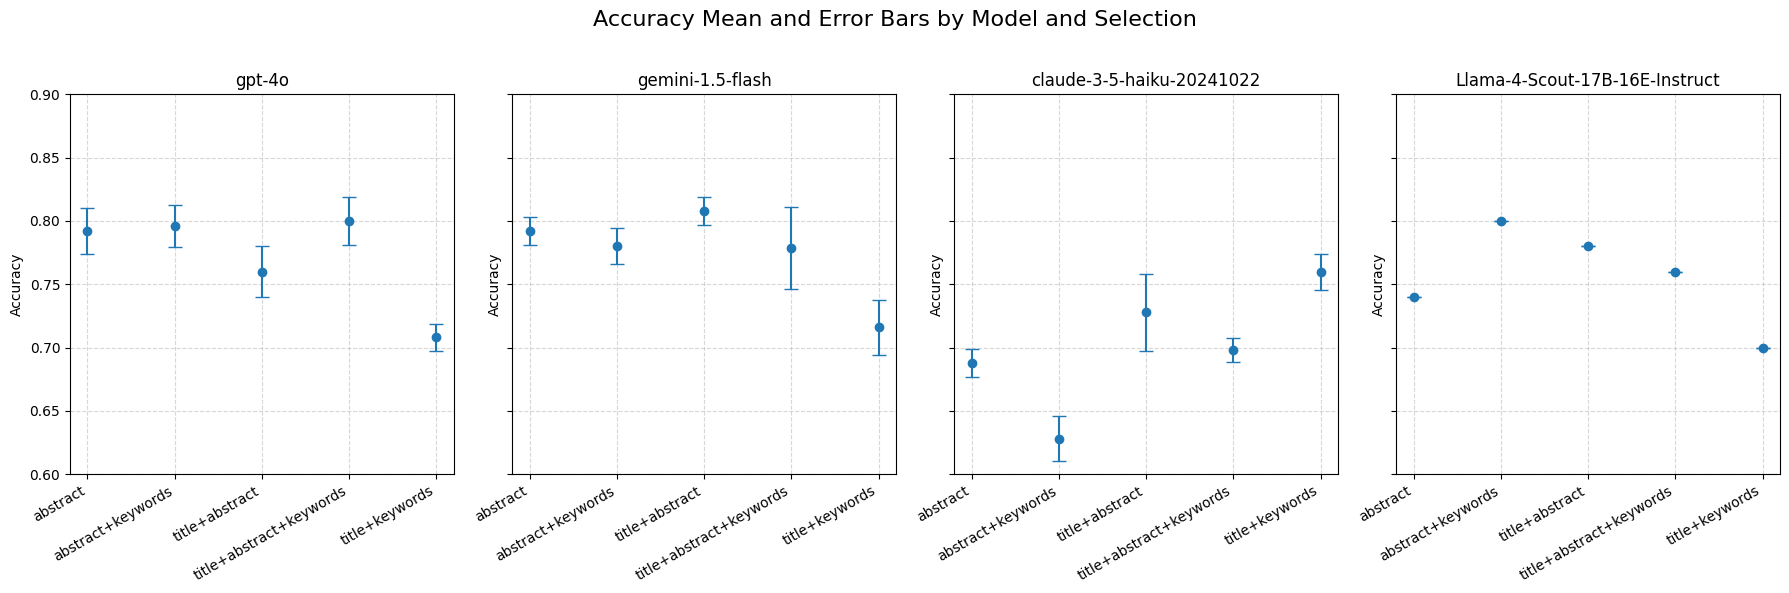

In [55]:

# Seleciona os três modelos principais
modelos_plot = ['gpt-4o', 'gemini-1.5-flash', 'claude-3-5-haiku-20241022','Llama-4-Scout-17B-16E-Instruct']
selections = df_summary['Selection'].unique()

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)

for idx, modelo in enumerate(modelos_plot):
    df_plot = df_summary[df_summary['Model'] == modelo]
    x = np.arange(len(df_plot['Selection']))
    y = df_plot['Accuracy_Mean']
    yerr = [y - df_plot['Accuracy_Lower'], df_plot['Accuracy_Upper'] - y]

    axes[idx].errorbar(x, y, yerr=yerr, fmt='o', capsize=5, label='Accuracy')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(df_plot['Selection'], rotation=30, ha='right')
    axes[idx].set_title(modelo)
    axes[idx].set_ylim(0.6, 0.9)
    axes[idx].set_ylabel('Accuracy')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Accuracy Mean and Error Bars by Model and Selection', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

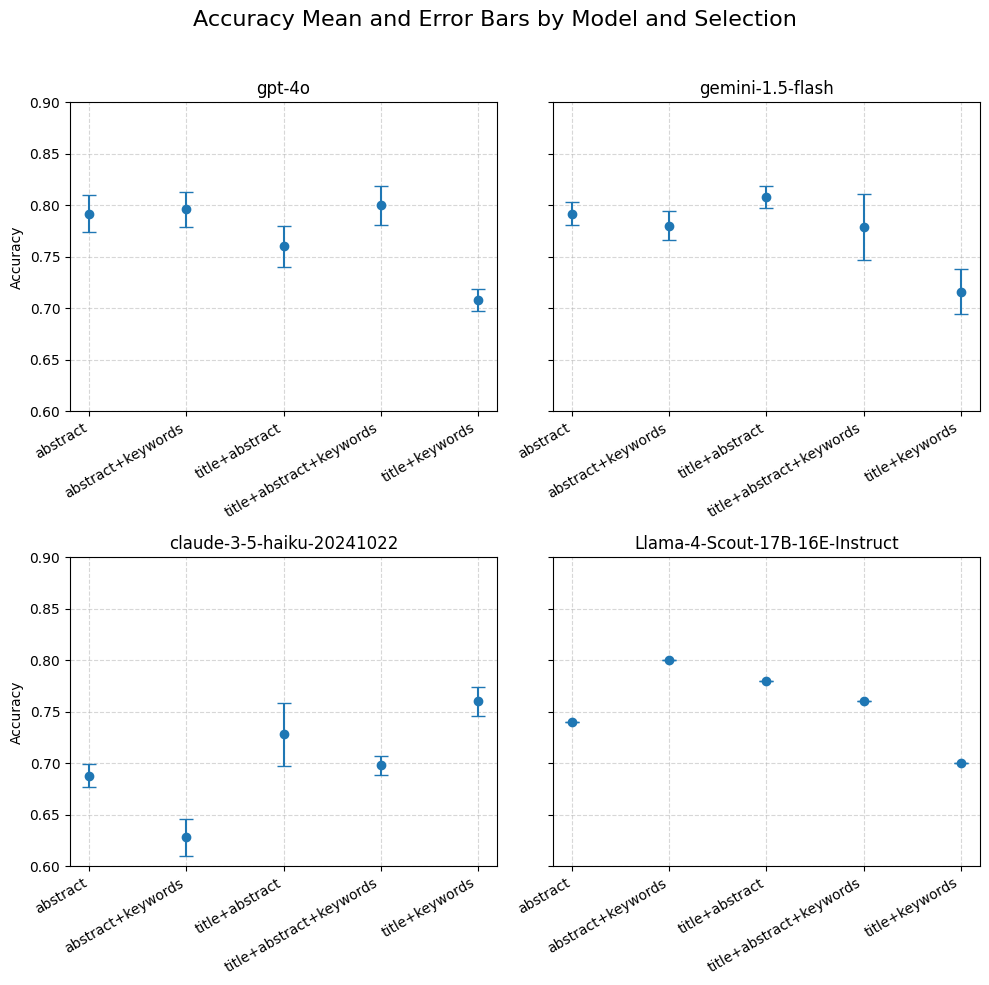

In [56]:
# Supondo que já existam: df_summary, np (NumPy) e plt (matplotlib.pyplot)

modelos_plot = ['gpt-4o', 'gemini-1.5-flash', 'claude-3-5-haiku-20241022', 'Llama-4-Scout-17B-16E-Instruct']

# Grade 2 x 2 em vez de 1 x 4
fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)  # sharey para mesma escala no eixo Y
axes_flat = axes.flat  # vetoriza os eixos para indexação simples

for idx, modelo in enumerate(modelos_plot):
    ax = axes_flat[idx]
    df_plot = df_summary[df_summary['Model'] == modelo].copy()

    # Garantir ordem consistente de Selection (opcional)
    df_plot = df_plot.sort_values('Selection')
    x = np.arange(len(df_plot['Selection']))
    y = df_plot['Accuracy_Mean'].to_numpy()
    yerr = np.vstack([
        (y - df_plot['Accuracy_Lower'].to_numpy()),
        (df_plot['Accuracy_Upper'].to_numpy() - y)
    ])

    ax.errorbar(x, y, yerr=yerr, fmt='o', capsize=5, label='Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot['Selection'], rotation=30, ha='right')
    ax.set_title(modelo)
    ax.set_ylim(0.6, 0.9)
    ax.grid(True, linestyle='--', alpha=0.5)
    if idx in (0, 2):  # primeira coluna
        ax.set_ylabel('Accuracy')

# Se houver mais “slots” que modelos, desativa os eixos sobrando
for j in range(len(modelos_plot), 4):
    axes_flat[j].set_axis_off()

fig.suptitle('Accuracy Mean and Error Bars by Model and Selection', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


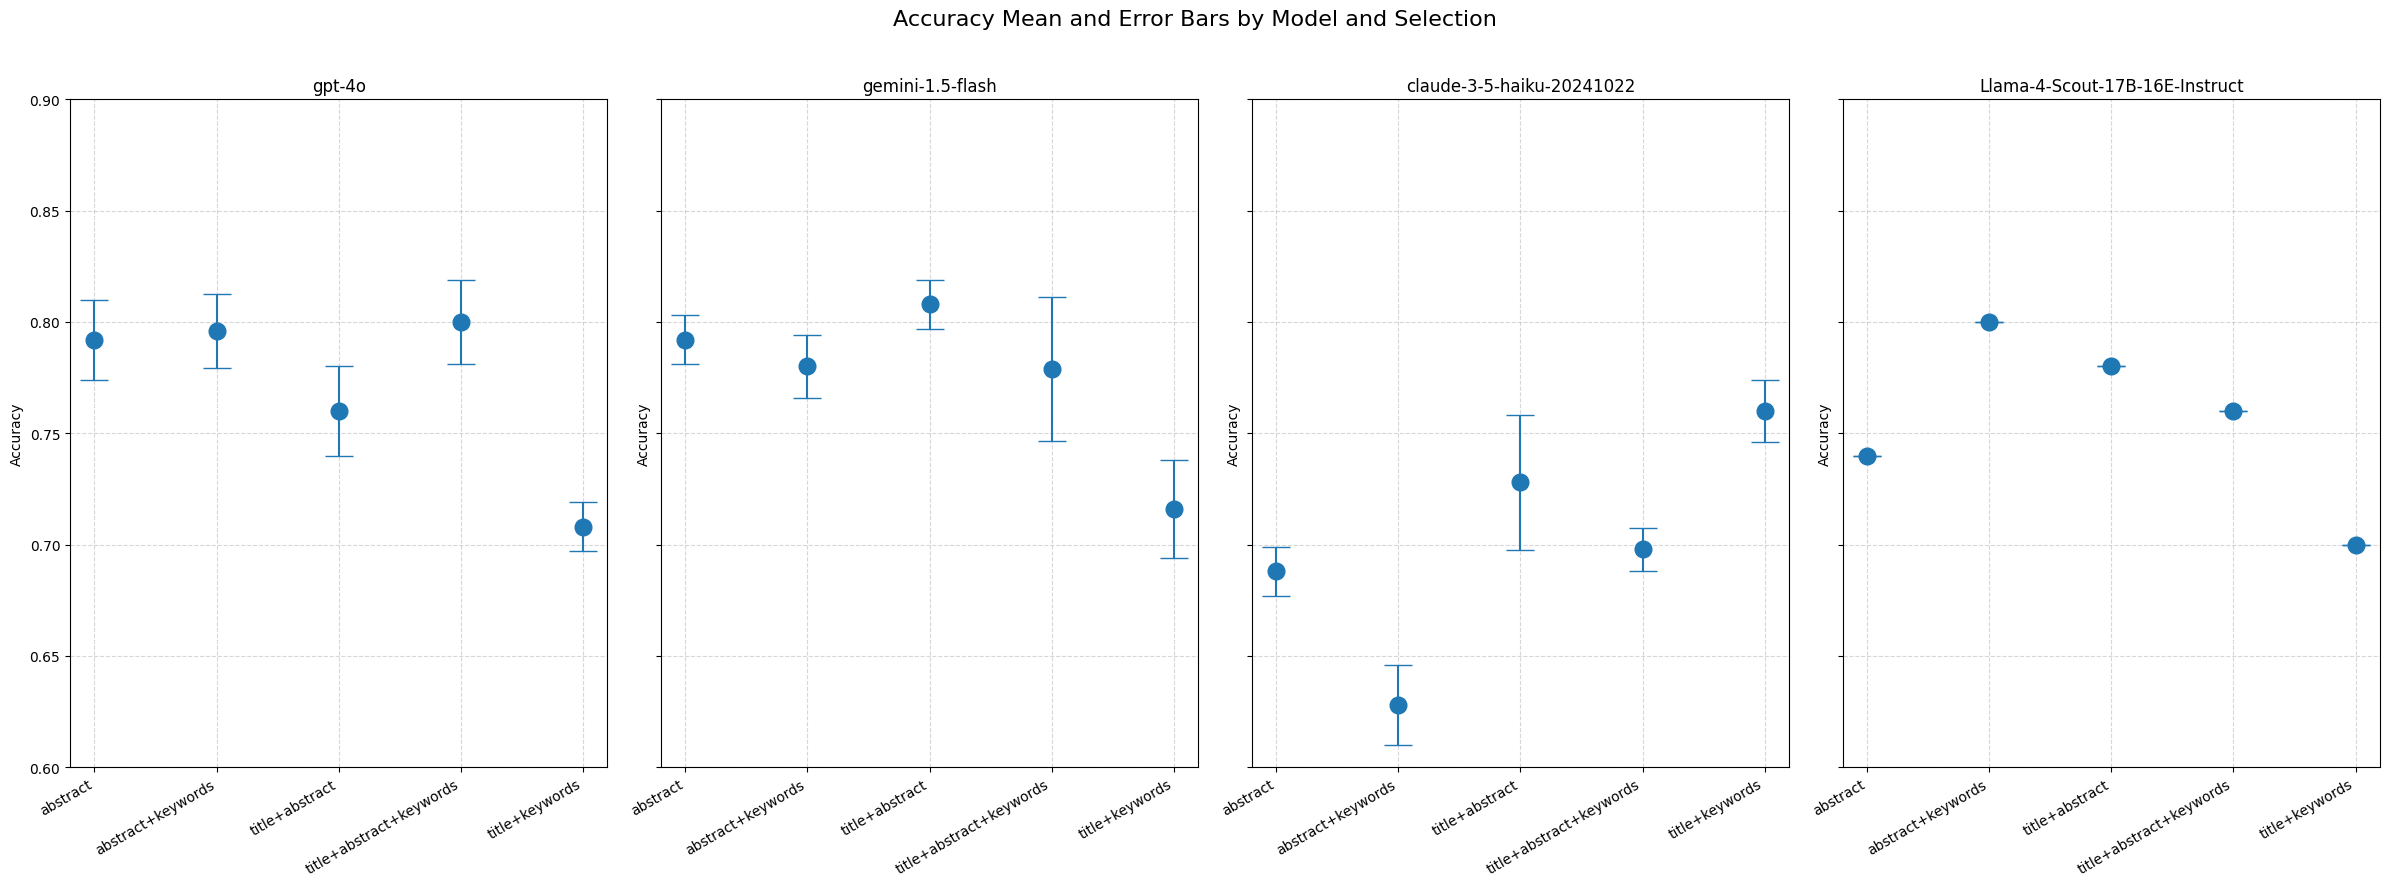

In [57]:
# Seleciona os três modelos principais
modelos_plot = ['gpt-4o', 'gemini-1.5-flash', 'claude-3-5-haiku-20241022','Llama-4-Scout-17B-16E-Instruct']
selections = df_summary['Selection'].unique()

fig, axes = plt.subplots(1, 4, figsize=(24, 9), sharey=True)

for idx, modelo in enumerate(modelos_plot):
    df_plot = df_summary[df_summary['Model'] == modelo]
    x = np.arange(len(df_plot['Selection']))
    y = df_plot['Accuracy_Mean']
    yerr = [y - df_plot['Accuracy_Lower'], df_plot['Accuracy_Upper'] - y]

    axes[idx].errorbar(x, y, yerr=yerr, fmt='o', capsize=10, label='Accuracy', markersize=12)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(df_plot['Selection'], rotation=30, ha='right')
    axes[idx].set_title(modelo)
    axes[idx].set_ylim(0.6, 0.9)
    axes[idx].set_ylabel('Accuracy')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Accuracy Mean and Error Bars by Model and Selection', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

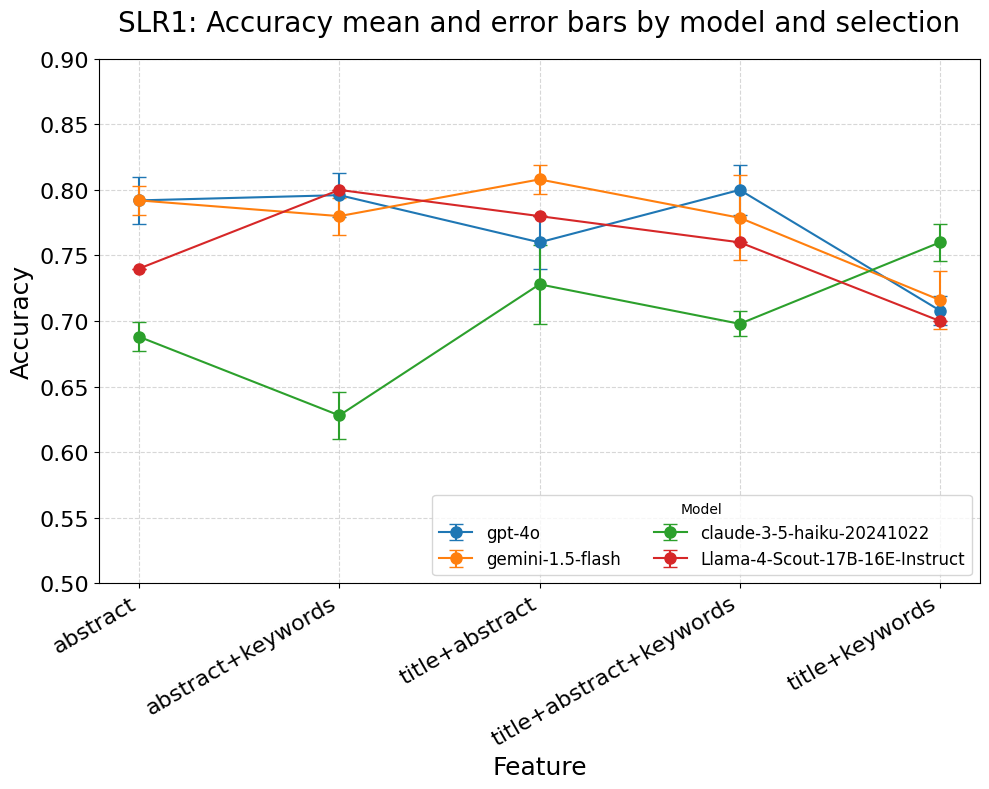

In [87]:
# Gráfico único com todas as séries de modelos em cores diferentes
modelos_plot = ['gpt-4o', 'gemini-1.5-flash', 'claude-3-5-haiku-20241022','Llama-4-Scout-17B-16E-Instruct']
colors = ['tab:blue', 'tab:orange', 'tab:green','tab:red']

fig, ax = plt.subplots(figsize=(10, 8))

for modelo, color in zip(modelos_plot, colors):
    df_plot = df_summary[df_summary['Model'] == modelo]
    x = np.arange(len(df_plot['Selection']))
    y = df_plot['Accuracy_Mean']
    yerr = [y - df_plot['Accuracy_Lower'], df_plot['Accuracy_Upper'] - y]
    ax.errorbar(x, y, yerr=yerr, fmt='o-', capsize=5, label=modelo, color=color, markersize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_plot['Selection'], rotation=30, ha='right')
ax.set_ylabel('Accuracy', fontsize=18)
ax.set_ylim(0.5, 0.9)
ax.set_title('SLR1: Accuracy mean and error bars by model and selection',pad=20, fontsize=20)

ax.set_xlabel('Feature', fontsize=18)
ax.tick_params(axis='both', labelsize=16)
ax.grid(True, linestyle='--', alpha=0.5)


ax.legend(title='Model', fontsize=12,loc='lower right', ncol=2)
plt.tight_layout()
plt.savefig('/data/codigos/dados/resultados/figuras/slr1_fase_2_comparativo_modelos.png', 
            dpi=300, bbox_inches='tight')
plt.show()

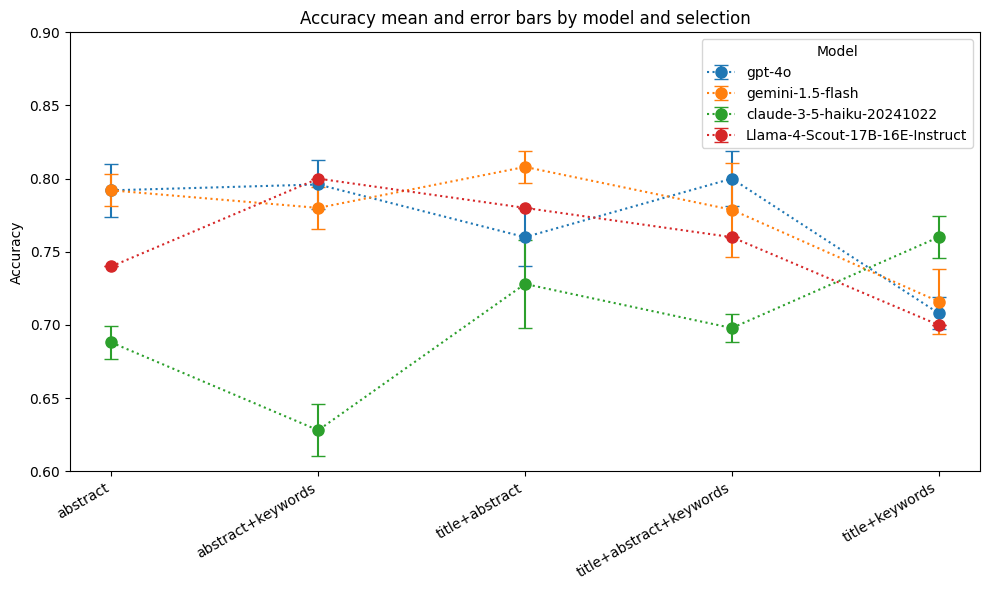

In [85]:
# Gráfico único com todas as séries de modelos em cores diferentes (linha pontilhada)
modelos_plot = ['gpt-4o', 'gemini-1.5-flash', 'claude-3-5-haiku-20241022','Llama-4-Scout-17B-16E-Instruct']
colors = ['tab:blue', 'tab:orange', 'tab:green','tab:red']

fig, ax = plt.subplots(figsize=(10, 6))

for modelo, color in zip(modelos_plot, colors):
    df_plot = df_summary[df_summary['Model'] == modelo]
    x = np.arange(len(df_plot['Selection']))
    y = df_plot['Accuracy_Mean']
    yerr = [y - df_plot['Accuracy_Lower'], df_plot['Accuracy_Upper'] - y]
    ax.errorbar(x, y, yerr=yerr, fmt='o:', capsize=5, label=modelo, color=color, markersize=8)  # fmt='o:' para linha pontilhada

ax.set_xticks(x)
ax.set_xticklabels(df_plot['Selection'], rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.6, 0.9)
ax.set_title('Accuracy mean and error bars by model and selection')
ax.legend(title='Model')
plt.tight_layout()
plt.show()

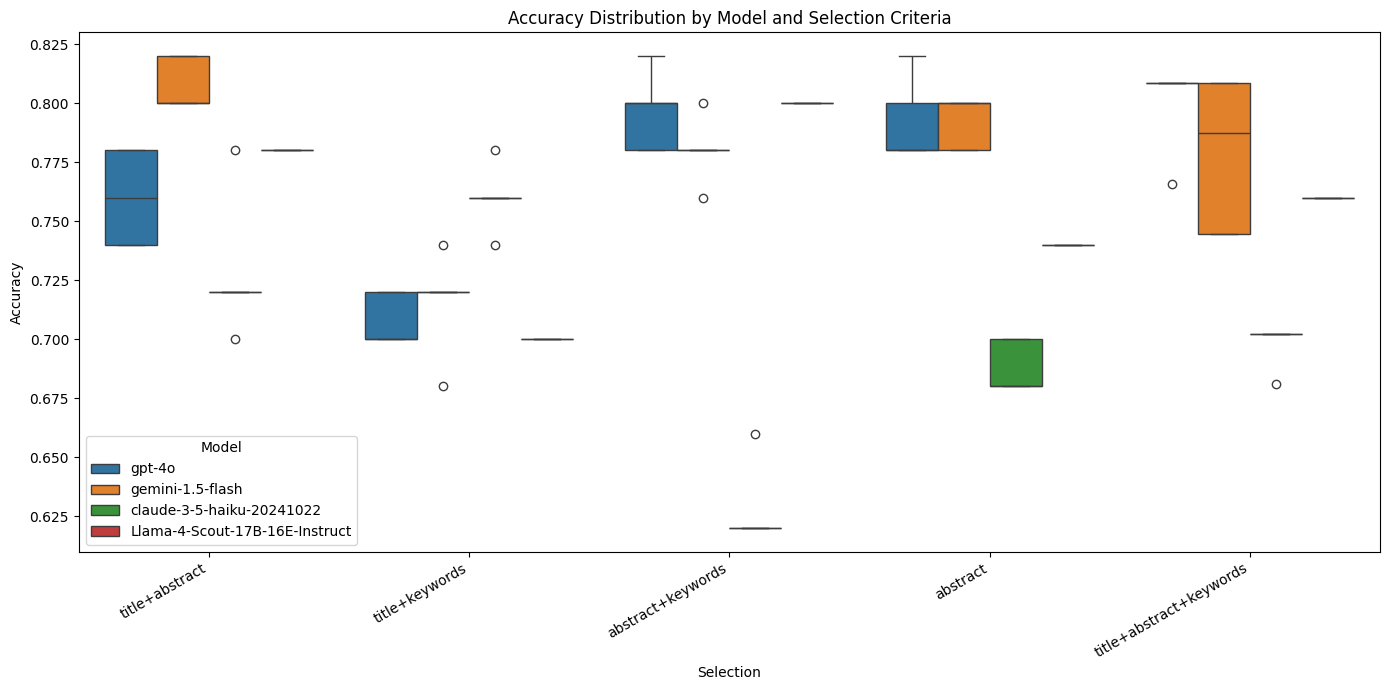

In [86]:



# Boxplot para comparar a distribuição das acurácias por modelo e seleção
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_acuracia, x="Selection", y="Accuracy", hue="Model")
plt.title("Accuracy Distribution by Model and Selection Criteria")
plt.ylabel("Accuracy")
plt.xlabel("Selection")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Model")
plt.tight_layout()
plt.show()